# Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv("ai diagnosis.csv")

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [4]:
#Dataset Information

print(df.shape)

df.info()

df.describe(include='all')

(10015, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


,lesion_id,image_id,dx,dx_type,age,sex,localization
count,10015,10015,10015,10015,9958.000000,10015,10015
unique,7470,10015,7,4,NaN,3,15
top,HAM_0003789,ISIC_0027419,nv,histo,NaN,male,back
freq,6,1,6705,5340,NaN,5406,2192
mean,NaN,NaN,NaN,NaN,51.863828,NaN,NaN
std,NaN,NaN,NaN,NaN,16.968614,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,40.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,50.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,65.000000,NaN,NaN


In [5]:
#missing values

df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [6]:
df["age"] = df["age"].fillna(df["age"].median())

In [7]:
print(df.duplicated().sum())

0


In [8]:
print(df["dx"].value_counts())

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [9]:
#Target classes

print(df["dx"].value_counts())

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


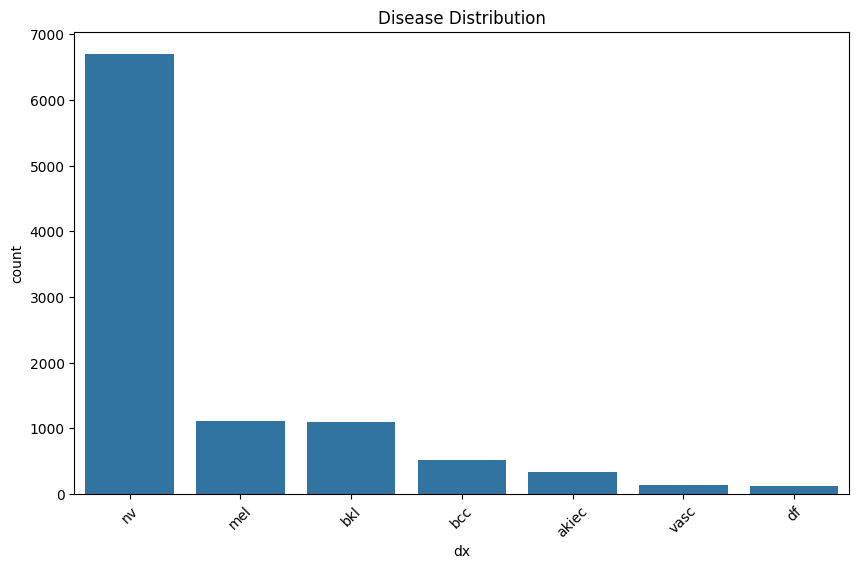

In [10]:
#visualization

plt.figure(figsize=(10,6))

sns.countplot(data=df,x="dx",order=df["dx"].value_counts().index)

plt.title("Disease Distribution")
plt.xticks(rotation=45)
plt.show()

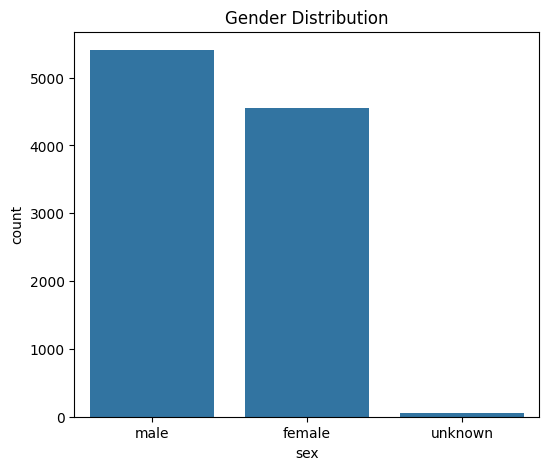

In [11]:
#Gender Distribution

plt.figure(figsize=(6,5))

sns.countplot(data=df,x="sex")

plt.title("Gender Distribution")
plt.show()

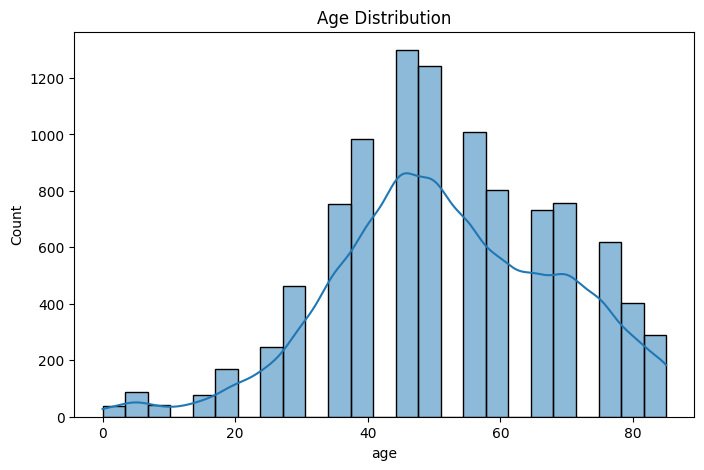

In [12]:
#Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["age"],bins=25,kde=True)

plt.title("Age Distribution")
plt.show()

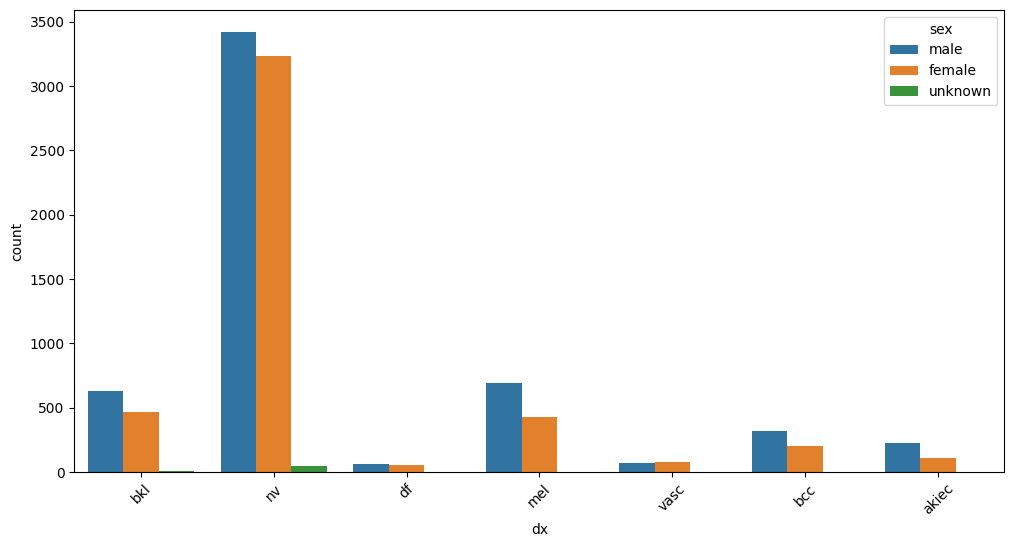

In [13]:
#Disease by Gender
plt.figure(figsize=(12,6))

sns.countplot(data=df,
              x="dx",
              hue="sex")

plt.xticks(rotation=45)
plt.show()

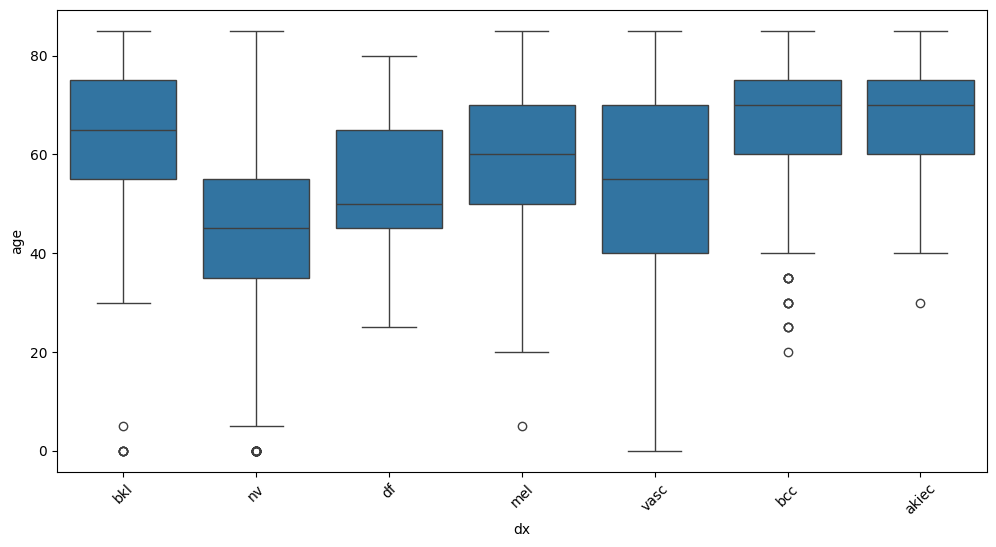

In [14]:
#Age by Disease
plt.figure(figsize=(12,6))

sns.boxplot(data=df,
            x="dx",
            y="age")

plt.xticks(rotation=45)
plt.show()

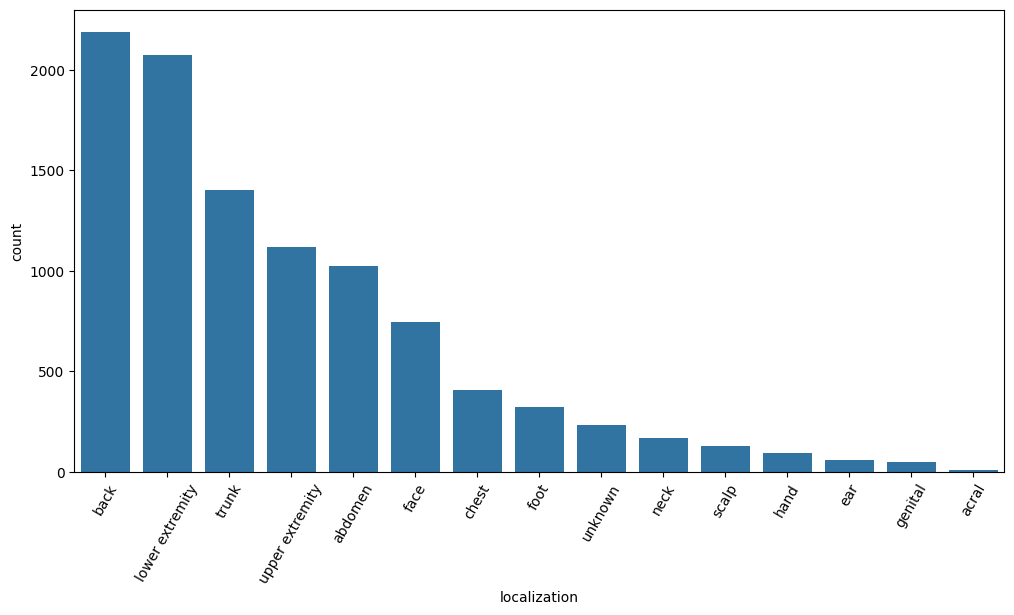

In [15]:
#body location distribution
plt.figure(figsize=(12,6))

sns.countplot(data=df,
              x="localization",
              order=df["localization"].value_counts().index)

plt.xticks(rotation=60)
plt.show()

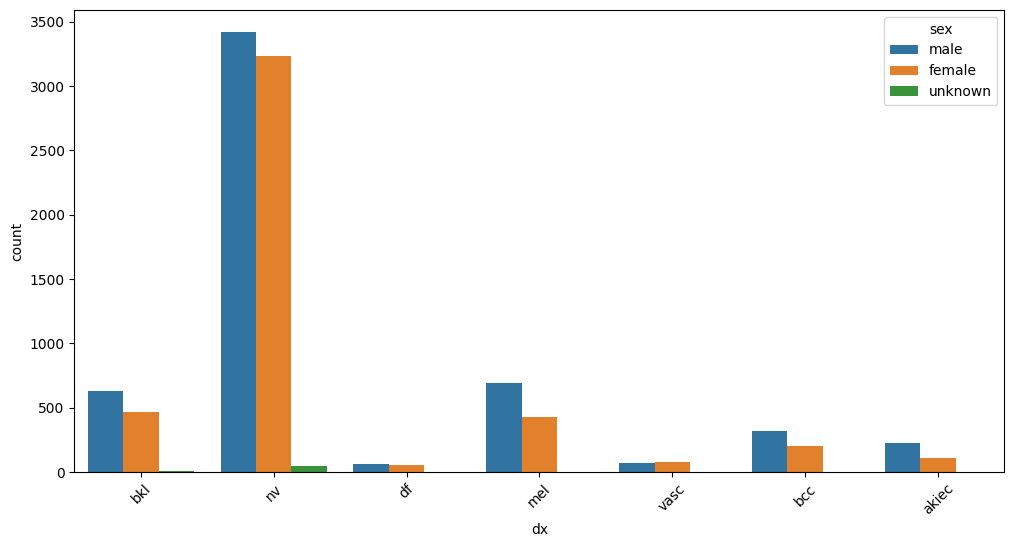

In [16]:
#Disease by gender
plt.figure(figsize=(12,6))

sns.countplot(data=df,
              x="dx",
              hue="sex")

plt.xticks(rotation=45)
plt.show()

In [17]:
#Encode categorical columns

encoder = LabelEncoder()

df["sex"] = encoder.fit_transform(df["sex"])

df["localization"] = encoder.fit_transform(df["localization"])

df["dx_type"] = encoder.fit_transform(df["dx_type"])

df["dx"] = encoder.fit_transform(df["dx"])

In [18]:
#Drop unnecessary columns

df = df.drop(["lesion_id", "image_id"],axis=1)

In [19]:
#Features and target

x = df.drop("dx",axis=1)

y = df["dx"]

In [20]:
# Train test split

x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
#Random forest
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
#Prediction
y_pred = model.predict(x_test)

In [23]:
#Accuracy
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

Accuracy: 0.72690963554668


In [25]:
#Classification report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.22      0.09      0.12        69
           1       0.29      0.24      0.26        93
           2       0.47      0.41      0.44       228
           3       0.73      0.29      0.41        28
           4       0.34      0.24      0.28       226
           5       0.83      0.95      0.89      1338
           6       0.50      0.33      0.40        21

    accuracy                           0.73      2003
   macro avg       0.48      0.36      0.40      2003
weighted avg       0.69      0.73      0.70      2003



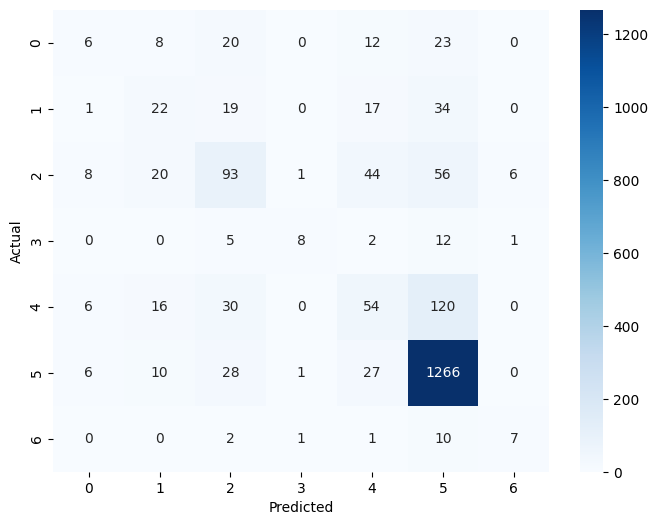

In [26]:
#confusion matrix
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

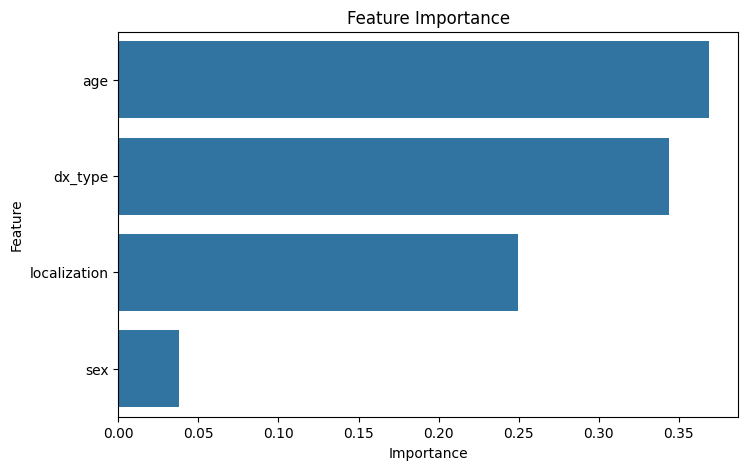

In [27]:
#Feature importance

importance = pd.DataFrame({
    "Feature":x.columns,
    "Importance":model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()